In [1]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [2]:
#Function 6
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 6.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Input 4', 'Input 5', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Input 3,Input 4,Input 5,Outputs
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


In [3]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5']])
Y = np.array(data[['Outputs']])


In [4]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Input 5,Outputs
Input 1,1.000000,-0.290118,0.068413,-0.029378,-0.269285,0.077437
Input 2,-0.290118,1.000000,0.074427,-0.156211,0.275815,-0.488390
Input 3,0.068413,0.074427,1.000000,0.132144,-0.110291,0.360415
Input 4,-0.029378,-0.156211,0.132144,1.000000,-0.355551,0.543378
Input 5,-0.269285,0.275815,-0.110291,-0.355551,1.000000,-0.587757
Outputs,0.077437,-0.488390,0.360415,0.543378,-0.587757,1.000000


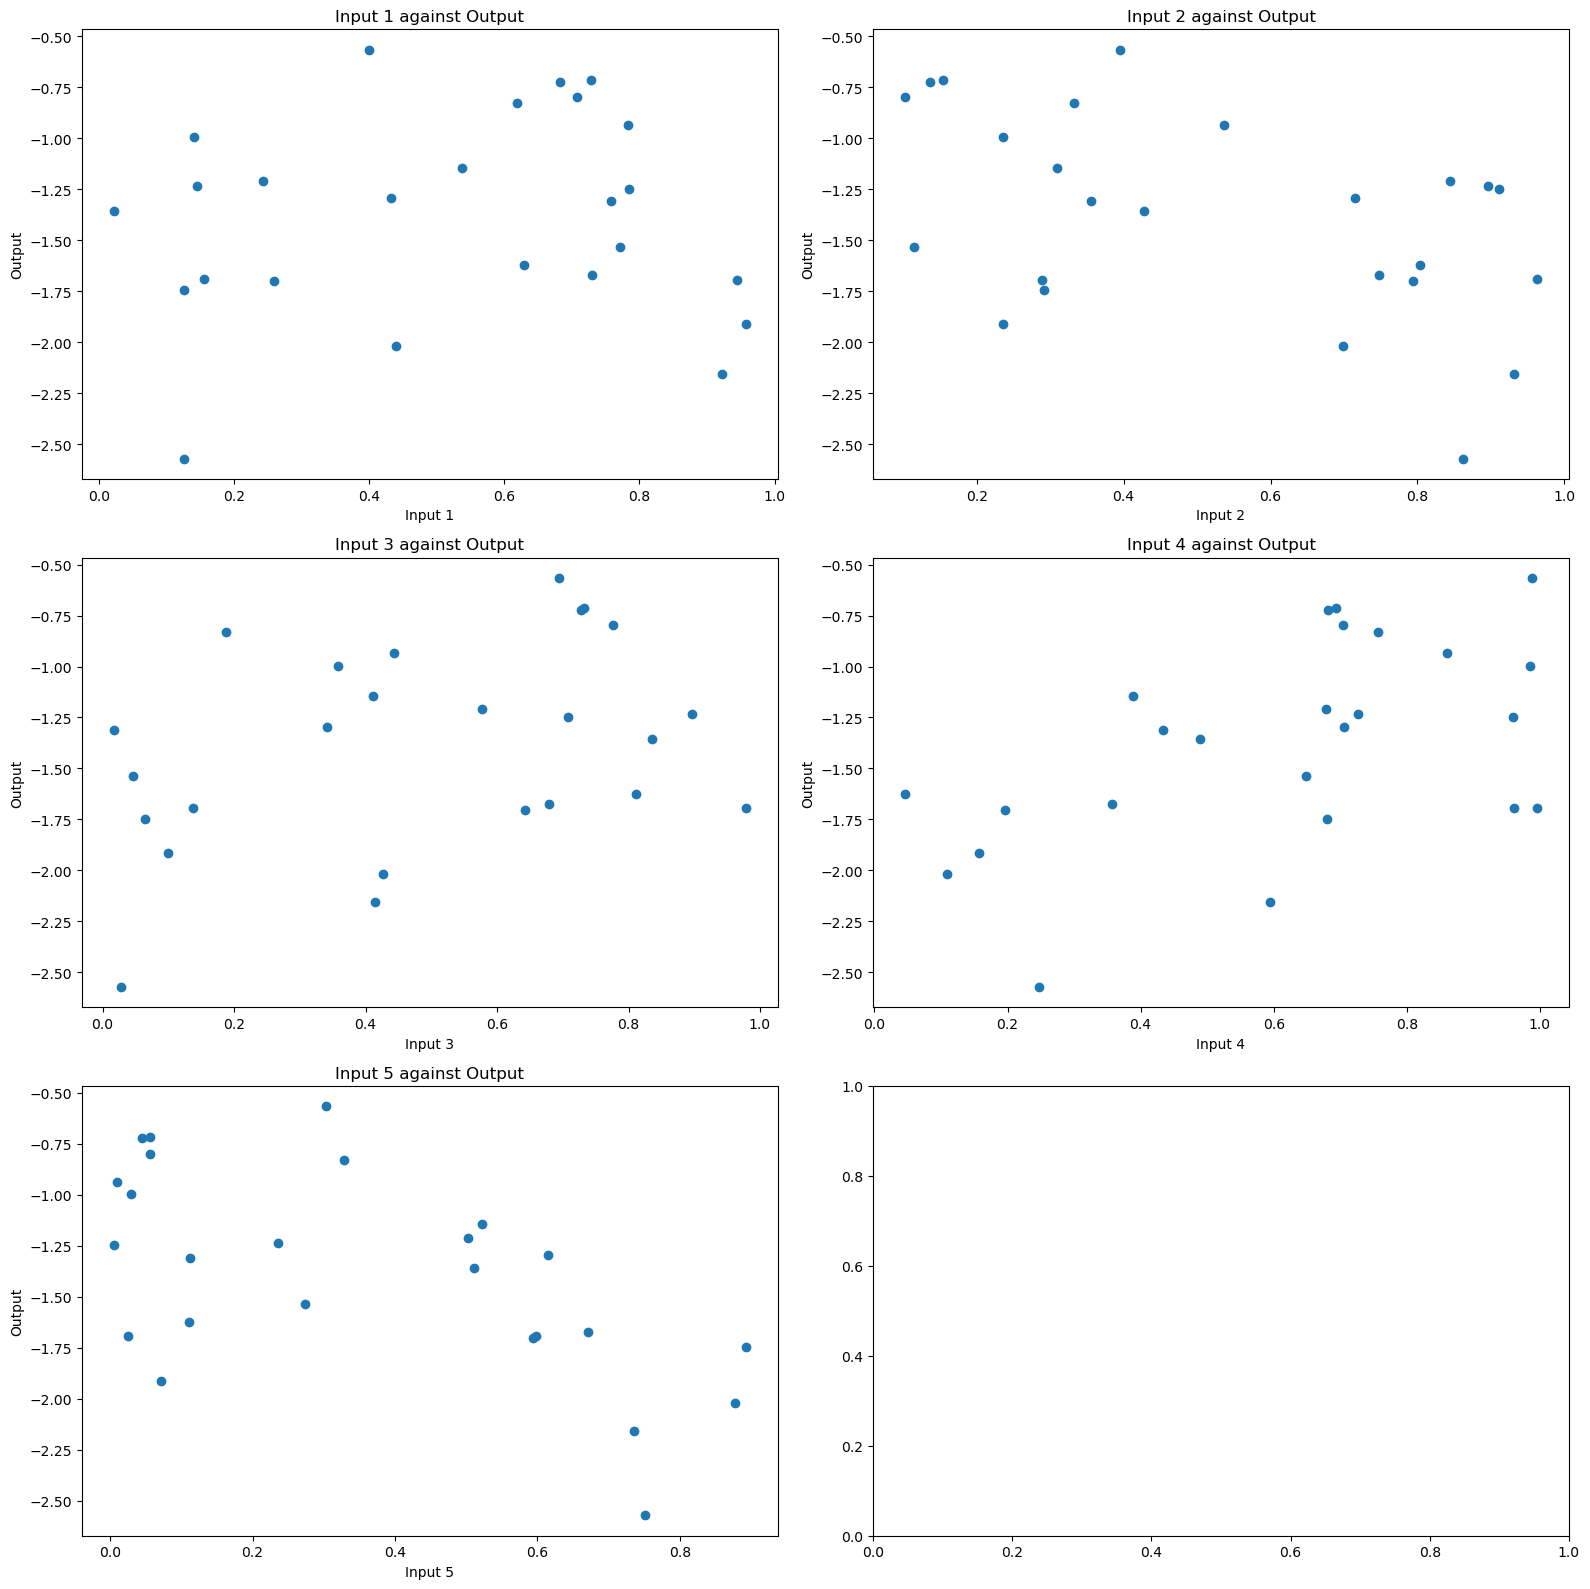

In [5]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,2, figsize = (16,16))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)
ax[2][0].scatter(X[:,4], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')
ax[2][0].set_title('Input 5 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

ax[2][0].set_xlabel('Input 5')
ax[2][0].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use latin hypercube sampling to create a set of candidate points 
d = 5
n = 500000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [10]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.46355 , 0.355337, 0.540706, 0.775973, 0.216895])

In [13]:
#Calculate UCB as comparison
beta = 3 #set exploration parameter
UCB = mu + beta * std
#Find candidate that maximises UCB
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.443695, 0.466007, 0.609481, 0.700804, 0.192006])